# Bayesian-FPDE Example

This notebook shows how to build an experimental Bayesian posterior over Hyb-FPDE `lambda_hyb` candidates, then use the posterior mean lambda for local and batch explanations.

In this v0.1.0 workflow, Bayesian-FPDE uncertainty is limited to the finite `lambda_hyb` grid. It does not sample class prototypes, estimate feature-level prototype uncertainty, or model black-box classifier uncertainty.

It uses the breast cancer dataset bundled with scikit-learn and keeps training, validation, and test samples separate:

- training data fits the classifier and class-mean FPDE prototypes
- validation data scores the lambda candidates with deletion and insertion curves
- test data receives the final posterior-mean-lambda Bayesian-FPDE explanations

In [1]:
from pathlib import Path
import sys
import importlib.util

for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "fpde").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break

missing = [pkg for pkg in ("matplotlib", "sklearn") if importlib.util.find_spec(pkg) is None]
if missing:
    raise RuntimeError(
        "Missing notebook dependencies: "
        + ", ".join(missing)
        + ". Install them with: python -m pip install -e \".[plot]\""
    )

print("Notebook dependencies are available.")

Notebook dependencies are available.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from fpde import (
    FPDEEngine,
    perturbation_curves,
    plot_attributions,
    plot_perturbation_curves,
)

## Fit A Classifier And FPDE Engine

The FPDE engine stores class-mean prototypes and the fitted classifier. The validation split is not used to fit either one; it is reserved for selecting the lambda posterior.

In [3]:
data = load_breast_cancer()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.20,
    random_state=13,
    stratify=data.target,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=13,
    stratify=y_train_full,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=13)
model.fit(X_train_scaled, y_train)

engine = FPDEEngine.fit(X_train_scaled, y_train, model=model)

print(f"Train samples: {X_train_scaled.shape[0]}")
print(f"Validation samples: {X_val_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Test accuracy: {model.score(X_test_scaled, y_test):.3f}")

Train samples: 341
Validation samples: 114
Test samples: 114
Test accuracy: 0.974


## Build The Bayesian Lambda Posterior

`select_bayesian_lambda` first evaluates each unique lambda candidate with held-out deletion and insertion validation. It then combines the validation score with a Beta prior over `lambda_hyb` and normalizes the resulting finite-grid posterior.

The credible interval reported here is an interval over lambda candidates, not a per-feature attribution interval.

In [4]:
lambda_grid = (0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0)
fractions = (0.0, 0.1, 0.25, 0.5, 0.75, 1.0)

selection = engine.select_bayesian_lambda(
    X_val_scaled,
    lambda_hyb_grid=lambda_grid,
    fractions=fractions,
    alpha=1.0,
    beta=1.0,
    temperature=0.5,
    credible_mass=0.90,
)

lo, hi = selection.credible_interval
print(f"Posterior mean lambda: {selection.posterior_mean_lambda:.3f}")
print(f"MAP lambda: {selection.map_lambda:.3f}")
print(f"90% credible interval: [{lo:.3f}, {hi:.3f}]")
print(f"Validation samples: {selection.n_eval_samples}")

Posterior mean lambda: 0.506
MAP lambda: 0.750
90% credible interval: [0.000, 1.000]
Validation samples: 114


Inspect the posterior mass and validation score for each lambda candidate. Higher posterior probability means the candidate was more supported by the validation objective and prior.

In [5]:
print("lambda_hyb  posterior  score    deletion_drop_auc  insertion_auc")
print("----------  ---------  -------  -----------------  -------------")
for row in selection.sorted_rows():
    print(
        f"{row['lambda_hyb']:10.2f}  "
        f"{row['posterior_probability']:9.3f}  "
        f"{row['score']:7.3f}  "
        f"{row['mean_deletion_drop_auc']:17.3f}  "
        f"{row['mean_insertion_auc']:13.3f}"
    )

lambda_hyb  posterior  score    deletion_drop_auc  insertion_auc
----------  ---------  -------  -----------------  -------------
      0.75      0.151    0.669              0.385          0.954
      0.10      0.147    0.669              0.384          0.954
      1.00      0.145    0.669              0.384          0.954
      0.25      0.144    0.669              0.384          0.954
      0.90      0.141    0.669              0.384          0.954
      0.50      0.140    0.669              0.384          0.954
      0.00      0.132    0.669              0.384          0.954


Plot the posterior mass assigned to each lambda candidate. The shaded band marks the Bayesian credible interval over `lambda_hyb`, while the vertical lines mark the posterior mean and MAP candidate.

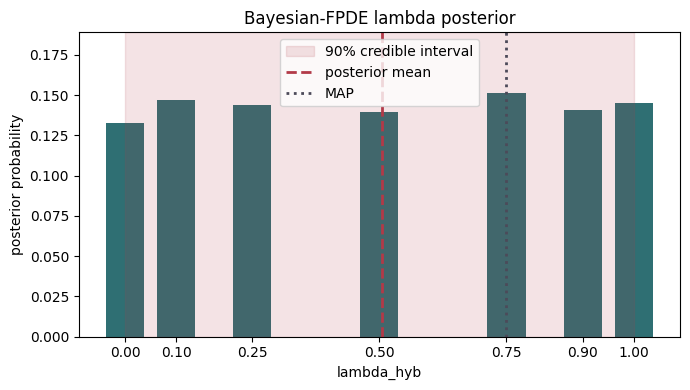

In [6]:
posterior_rows = sorted(selection.posterior_rows, key=lambda row: row["lambda_hyb"])
lambda_values = [row["lambda_hyb"] for row in posterior_rows]
posterior_probabilities = [row["posterior_probability"] for row in posterior_rows]
lo, hi = selection.credible_interval

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(lambda_values, posterior_probabilities, width=0.075, color="#2f6f73")
ax.axvspan(lo, hi, color="#b23a48", alpha=0.14, label="90% credible interval")
ax.axvline(selection.posterior_mean_lambda, color="#b23a48", linestyle="--", linewidth=2, label="posterior mean")
ax.axvline(selection.map_lambda, color="#4c4a59", linestyle=":", linewidth=2, label="MAP")
ax.set_xlabel("lambda_hyb")
ax.set_ylabel("posterior probability")
ax.set_title("Bayesian-FPDE lambda posterior")
ax.set_xticks(lambda_values)
ax.set_ylim(0.0, max(posterior_probabilities) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

## Explain One Test Sample

`explain_one_bayesian` uses `selection.posterior_mean_lambda`, so the attribution vector is the Bayesian model-averaged Hyb-FPDE explanation over the finite lambda grid. Because this posterior is over `lambda_hyb`, the result is a single expected attribution vector rather than a sampled-prototype attribution summary.

In [7]:
sample_idx = 0
x = X_test_scaled[sample_idx]

bayes_attr, bayes_details = engine.explain_one_bayesian(x, selection)
map_attr, map_details = engine.explain_one(
    x,
    lambda_hyb=selection.map_lambda,
    normalize=selection.normalize,
    anchor_strategy=selection.anchor_strategy,
    eps=selection.eps,
)
lo_attr, _ = engine.explain_one(
    x,
    lambda_hyb=lo,
    normalize=selection.normalize,
    anchor_strategy=selection.anchor_strategy,
    eps=selection.eps,
)
hi_attr, _ = engine.explain_one(
    x,
    lambda_hyb=hi,
    normalize=selection.normalize,
    anchor_strategy=selection.anchor_strategy,
    eps=selection.eps,
)
bayes_interval_low = np.minimum(lo_attr, hi_attr)
bayes_interval_high = np.maximum(lo_attr, hi_attr)

print(f"True class: {y_test[sample_idx]}")
print(f"Predicted target class: {bayes_details['target_label']}")
print(f"Rival class: {bayes_details['rival_label']}")
print(f"Target probability: {bayes_details['target_probability']:.3f}")
print(f"Posterior mean lambda used: {bayes_details['posterior_mean_lambda']:.3f}")
print(f"Bayesian evidence: {bayes_details['evidence']:.4f}")
print(f"MAP-lambda evidence: {map_details['evidence']:.4f}")
print(f"Mean absolute attribution difference: {np.mean(np.abs(bayes_attr - map_attr)):.4f}")

True class: 0
Predicted target class: 0
Rival class: 1
Target probability: 1.000
Posterior mean lambda used: 0.506
Bayesian evidence: 0.8316
MAP-lambda evidence: 0.8108
Mean absolute attribution difference: 0.0008


Positive attribution values support the predicted target class relative to the rival class. Negative values support the rival class relative to the target class.

Interpret these values as posterior-mean-lambda FPDE contributions. They are not feature-level posterior means or credible intervals from sampled class prototypes.

In [8]:
feature_names = np.asarray(data.feature_names, dtype=object)
order = np.argsort(bayes_attr)

print("Top positive Bayesian-FPDE feature contributions:")
for idx in order[-5:][::-1]:
    print(f"  {feature_names[idx]}: {bayes_attr[idx]: .4f}")

print("\nTop negative Bayesian-FPDE feature contributions:")
for idx in order[:5]:
    print(f"  {feature_names[idx]}: {bayes_attr[idx]: .4f}")

Top positive Bayesian-FPDE feature contributions:
  worst radius:  0.0952
  mean area:  0.0945
  mean radius:  0.0945
  worst perimeter:  0.0929
  mean perimeter:  0.0912

Top negative Bayesian-FPDE feature contributions:
  concave points error: -0.0213
  compactness error: -0.0148
  perimeter error: -0.0104
  concavity error: -0.0075
  worst fractal dimension: -0.0068


Visualize the largest signed Bayesian-FPDE contributions for the same sample. The horizontal caps show the attribution range induced by the Bayesian credible interval over `lambda_hyb`.

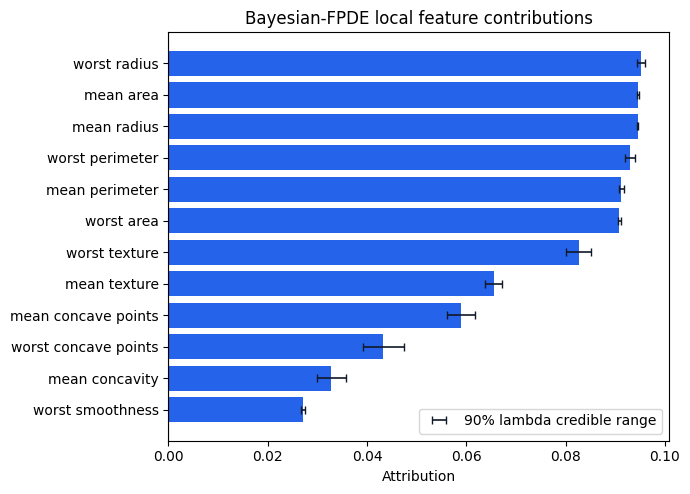

In [9]:
ax = plot_attributions(
    bayes_attr,
    feature_names=feature_names,
    top_k=12,
    interval_low=bayes_interval_low,
    interval_high=bayes_interval_high,
    interval_label="90% lambda credible range",
    title="Bayesian-FPDE local feature contributions",
)
plt.tight_layout()
plt.show()

Deletion and insertion curves check how the attribution ranking behaves when important features are removed or introduced against the FPDE baseline.

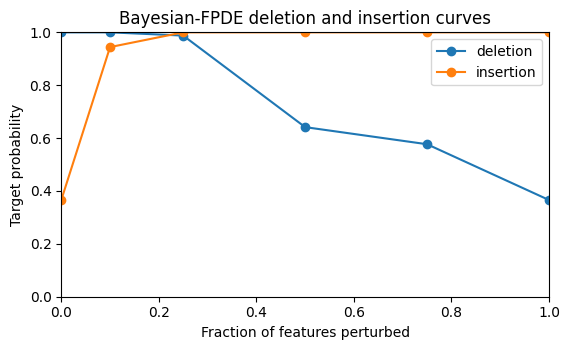

Deletion drop AUC: 0.2772
Insertion AUC: 0.9613
Combined score: 0.6193


In [10]:
curves = perturbation_curves(
    model,
    x,
    bayes_attr,
    bayes_details["target_label"],
    engine.baseline,
    fractions=fractions,
)

ax = plot_perturbation_curves(curves, title="Bayesian-FPDE deletion and insertion curves")
plt.tight_layout()
plt.show()

print(f"Deletion drop AUC: {curves['deletion_drop_auc']:.4f}")
print(f"Insertion AUC: {curves['insertion_auc']:.4f}")
print(f"Combined score: {curves['combined_score']:.4f}")

## Explain A Batch

The batch API reuses the same posterior mean lambda and returns one attribution vector per sample. The same scope applies here: Bayesian uncertainty has already been summarized into `selection.posterior_mean_lambda`.

In [11]:
batch_attr, batch_details = engine.explain_batch_bayesian(X_test_scaled[:8], selection)

def as_python_scalar(value):
    return value.item() if hasattr(value, "item") else value

print(f"Batch attribution matrix shape: {batch_attr.shape}")
print(f"Mean absolute attribution: {np.mean(np.abs(batch_attr)):.4f}")
print("Target labels:", [as_python_scalar(row["target_label"]) for row in batch_details])
print("Rival labels:", [as_python_scalar(row["rival_label"]) for row in batch_details])

Batch attribution matrix shape: (8, 30)
Mean absolute attribution: 0.0333
Target labels: [0, 1, 0, 0, 1, 1, 0, 1]
Rival labels: [1, 0, 1, 1, 0, 0, 1, 0]
